In [2]:
import os
import matplotlib.pyplot
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, \
    Dropout, GlobalMaxPooling2D, Activation, Rescaling

physical_devices = tf.config.list_physical_devices("GPU")
# Check to see if there are any physical GPUs
if len(physical_devices) > 0:
    # Only try to set memory growth if there are any GPUs
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
# If no GPUs print a message
else:
    print("No GPUs found. TensorFlow will use CPU.")

No GPUs found. TensorFlow will use CPU.


In [3]:
(ds_train, ds_test), ds_info = tfds.load(
    "mnist",
    split=["train", "test"],
    shuffle_files=True,
    as_supervised=True,  # will return tuple (img, label) otherwise dict
    with_info=True,  # able to get info about dataset
)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [4]:
image_shape = ds_info.features["image"].shape
print(f'Shape of Images in the Dataset: \t{image_shape}')

num_classes = ds_info.features["label"].num_classes
print(f'Number of Classes in the Dataset: \t{num_classes}')

names_of_classes = ds_info.features["label"].names
print(f'Names of Classes in the Dataset: \t{names_of_classes}\n')

for name in names_of_classes:
    print(f'Label for class \
          "{name}":  \t\t{ds_info.features["label"].str2int(name)}')

Shape of Images in the Dataset: 	(28, 28, 1)
Number of Classes in the Dataset: 	10
Names of Classes in the Dataset: 	['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Label for class           "0":  		0
Label for class           "1":  		1
Label for class           "2":  		2
Label for class           "3":  		3
Label for class           "4":  		4
Label for class           "5":  		5
Label for class           "6":  		6
Label for class           "7":  		7
Label for class           "8":  		8
Label for class           "9":  		9


In [5]:
print(f'Total examples in Train Dataset: \
      \t{len(ds_train)}')
print(f'Total examples in Test Dataset: \
      \t{len(ds_test)}')

Total examples in Train Dataset:       	60000
Total examples in Test Dataset:       	10000


In [6]:

def normalize_img(image, label):
    """Normalizes images"""
    return tf.cast(image, tf.float32) / 255.0, label

In [7]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
BATCH_SIZE = 128

In [8]:
# Setup for train dataset
ds_train = ds_train.map(normalize_img, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits["train"].num_examples)
ds_train = ds_train.batch(BATCH_SIZE)
ds_train = ds_train.prefetch(AUTOTUNE)

In [9]:
# Setup for test Dataset
ds_test = ds_train.map(normalize_img, num_parallel_calls=AUTOTUNE)
ds_test = ds_train.batch(128)
ds_test = ds_train.prefetch(AUTOTUNE)

In [10]:
model = keras.Sequential(
    [
        keras.Input((28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", strides=2),
        layers.Conv2D(64, 3, activation='relu', strides=2),
        layers.Flatten(),
        Dropout(rate=0.2),
        layers.Dense(512, activation="relu"),
        Dropout(rate=0.2),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [12]:
history = model.fit(ds_train, validation_data=ds_test, epochs=15, verbose=2)

Epoch 1/15
469/469 - 44s - 94ms/step - accuracy: 0.9299 - loss: 0.2376 - val_accuracy: 0.9792 - val_loss: 0.0692
Epoch 2/15
469/469 - 74s - 157ms/step - accuracy: 0.9784 - loss: 0.0701 - val_accuracy: 0.9897 - val_loss: 0.0358
Epoch 3/15
469/469 - 34s - 74ms/step - accuracy: 0.9839 - loss: 0.0498 - val_accuracy: 0.9927 - val_loss: 0.0248
Epoch 4/15
469/469 - 45s - 95ms/step - accuracy: 0.9875 - loss: 0.0380 - val_accuracy: 0.9951 - val_loss: 0.0178
Epoch 5/15
469/469 - 39s - 82ms/step - accuracy: 0.9909 - loss: 0.0285 - val_accuracy: 0.9961 - val_loss: 0.0130
Epoch 6/15
469/469 - 39s - 83ms/step - accuracy: 0.9915 - loss: 0.0252 - val_accuracy: 0.9974 - val_loss: 0.0093
Epoch 7/15
469/469 - 35s - 75ms/step - accuracy: 0.9930 - loss: 0.0205 - val_accuracy: 0.9975 - val_loss: 0.0082
Epoch 8/15
469/469 - 34s - 72ms/step - accuracy: 0.9951 - loss: 0.0156 - val_accuracy: 0.9984 - val_loss: 0.0058
Epoch 9/15
469/469 - 41s - 87ms/step - accuracy: 0.9946 - loss: 0.0157 - val_accuracy: 0.9988 -

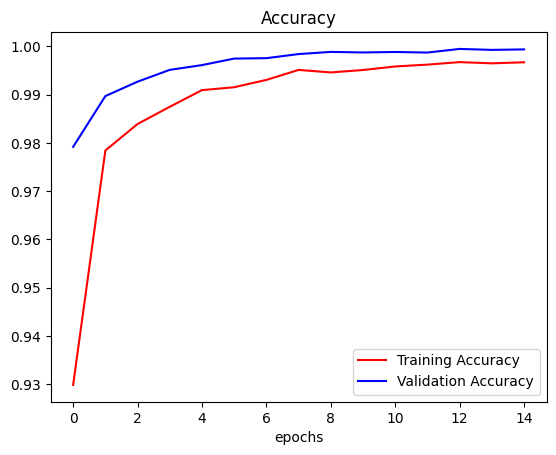

<Figure size 640x480 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt

def plot_trend_by_epoch(tr_values, val_values, title):
        epoch_number = range(len(tr_values))
        plt.plot(epoch_number, tr_values, 'r')
        plt.plot(epoch_number, val_values, 'b')
        plt.title(title)
        plt.xlabel('epochs')
        plt.legend(['Training '+title, 'Validation '+title])
        plt.figure()
hist_dict = history.history
tr_accuracy, val_accuracy = hist_dict['accuracy'], \
                                hist_dict['val_accuracy']
plot_trend_by_epoch(tr_accuracy, val_accuracy, "Accuracy")

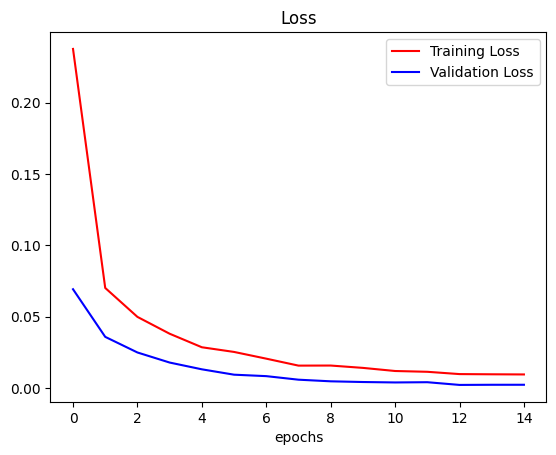

<Figure size 640x480 with 0 Axes>

In [14]:
tr_loss, val_loss = hist_dict['loss'], hist_dict['val_loss']
plot_trend_by_epoch(tr_loss, val_loss, "Loss")